# Audio Features and Classical Baselines

This notebook verifies the reusable audio pipeline and compares four classifiers on the predefined ESC-50 split. Folds 1–4 are used for training and fold 5 is used only for evaluation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from sound_recognition.audio import AudioConfig, load_audio
from sound_recognition.dataset import load_esc50_metadata
from sound_recognition.experiments import run_experiment
from sound_recognition.features import extract_features, feature_names

# Notebook execution can start either in the repository root or in the
# notebooks directory. Resolving the root here keeps every path reproducible.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIRECTORY = PROJECT_ROOT / "data" / "ESC-50"
RESULTS_DIRECTORY = PROJECT_ROOT / "artifacts" / "results"
FEATURE_CACHE = PROJECT_ROOT / "artifacts" / "cache" / "esc50_features.npz"

config = AudioConfig()
metadata = load_esc50_metadata(DATASET_DIRECTORY)
print(f"Recordings: {len(metadata):,}")
print(
    f"Standard format: mono, {config.sample_rate} Hz, {config.duration_seconds:.1f} s"
)
print(f"Samples per recording: {config.number_of_samples:,}")
print(f"Features per recording: {len(feature_names(config))}")

Recordings: 2,000
Standard format: mono, 22050 Hz, 5.0 s
Samples per recording: 110,250
Features per recording: 154


## Verify preprocessing on several sound classes

The same `load_audio` and `extract_features` functions are used here, in model training, and later in the prediction API.

In [2]:
example_categories = ["dog", "keyboard_typing", "rain", "sea_waves", "siren"]
examples = (
    metadata.loc[metadata["category"].isin(example_categories)]
    .groupby("category", sort=True)
    .first()
    .reset_index()
)

# Each row below is produced independently from one waveform. Equal row
# lengths confirm that differently shaped sounds share one model input format.
example_features = np.vstack(
    [
        extract_features(load_audio(row.audio_path, config), config)
        for row in examples.itertuples()
    ]
)
example_table = pd.DataFrame(
    example_features,
    index=examples["category"],
    columns=feature_names(config),
)
selected_columns = [
    "mfcc_01_mean",
    "mfcc_02_mean",
    "chroma_01_mean",
    "spectral_centroid_01_mean",
    "rms_01_mean",
]
display(example_table[selected_columns].round(3))

,mfcc_01_mean,mfcc_02_mean,chroma_01_mean,spectral_centroid_01_mean,rms_01_mean
category,,,,,
dog,-877.004028,4.694000,0.064,217.341995,0.004
keyboard_typing,-443.960999,63.706001,0.829,2645.863037,0.009
rain,-278.007996,74.927002,0.903,3227.964111,0.076
sea_waves,-344.829987,100.066002,0.860,2361.620117,0.086
siren,-650.715027,152.279999,0.261,1030.047974,0.111


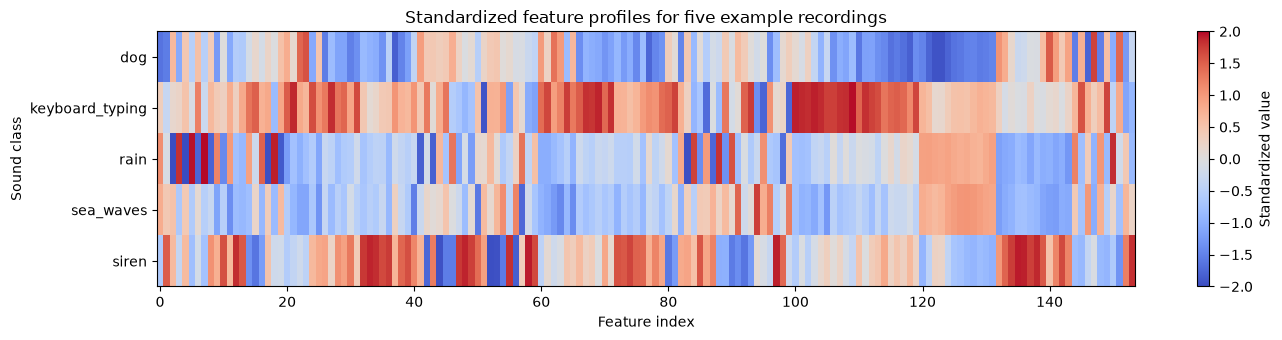

In [3]:
# Standardization is used only for this visualization so features with large
# numerical ranges do not dominate the colour scale. Model pipelines perform
# their own scaling and never use information from the test fold during fit.
standardized_examples = (
    example_features - example_features.mean(axis=0, keepdims=True)
) / (example_features.std(axis=0, keepdims=True) + 1e-8)

figure, axis = plt.subplots(figsize=(14, 3.5))
image = axis.imshow(
    standardized_examples, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2
)
axis.set(
    title="Standardized feature profiles for five example recordings",
    xlabel="Feature index",
    ylabel="Sound class",
    yticks=np.arange(len(examples)),
)
axis.set_yticklabels(examples["category"])
figure.colorbar(image, ax=axis, label="Standardized value")
figure.tight_layout()
plt.show()

## Train and evaluate baseline models

The first run extracts features for all 2,000 files and writes an ignored local cache. Later runs load that cache and only retrain the four small estimators.

In [4]:
results = run_experiment(
    dataset_directory=DATASET_DIRECTORY,
    output_directory=RESULTS_DIRECTORY,
    cache_path=FEATURE_CACHE,
)
display(
    results.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "fit_seconds": "{:.3f}",
            "prediction_ms_per_recording": "{:.4f}",
        }
    )
)

Loading cached features from /Users/rxffstxr/University/machine-learning/sound-recognition/artifacts/cache/esc50_features.npz
Training: Most frequent class
Training: Logistic regression
Training: RBF support vector machine


Training: Random forest



Model comparison on ESC-50 fold 5:
                     model  accuracy  macro_f1  fit_seconds  prediction_ms_per_recording
RBF support vector machine    0.5525  0.540977     0.155185                     0.139860
             Random forest    0.5575  0.530084     0.631850                     0.063539
       Logistic regression    0.4950  0.484618     0.112823                     0.000629
       Most frequent class    0.0200  0.000784     0.003073                     0.000069

Most promising model: RBF support vector machine


,model,accuracy,macro_f1,fit_seconds,prediction_ms_per_recording
0,RBF support vector machine,0.5525,0.5410,0.155,0.1399
1,Random forest,0.5575,0.5301,0.632,0.0635
2,Logistic regression,0.4950,0.4846,0.113,0.0006
3,Most frequent class,0.0200,0.0008,0.003,0.0001


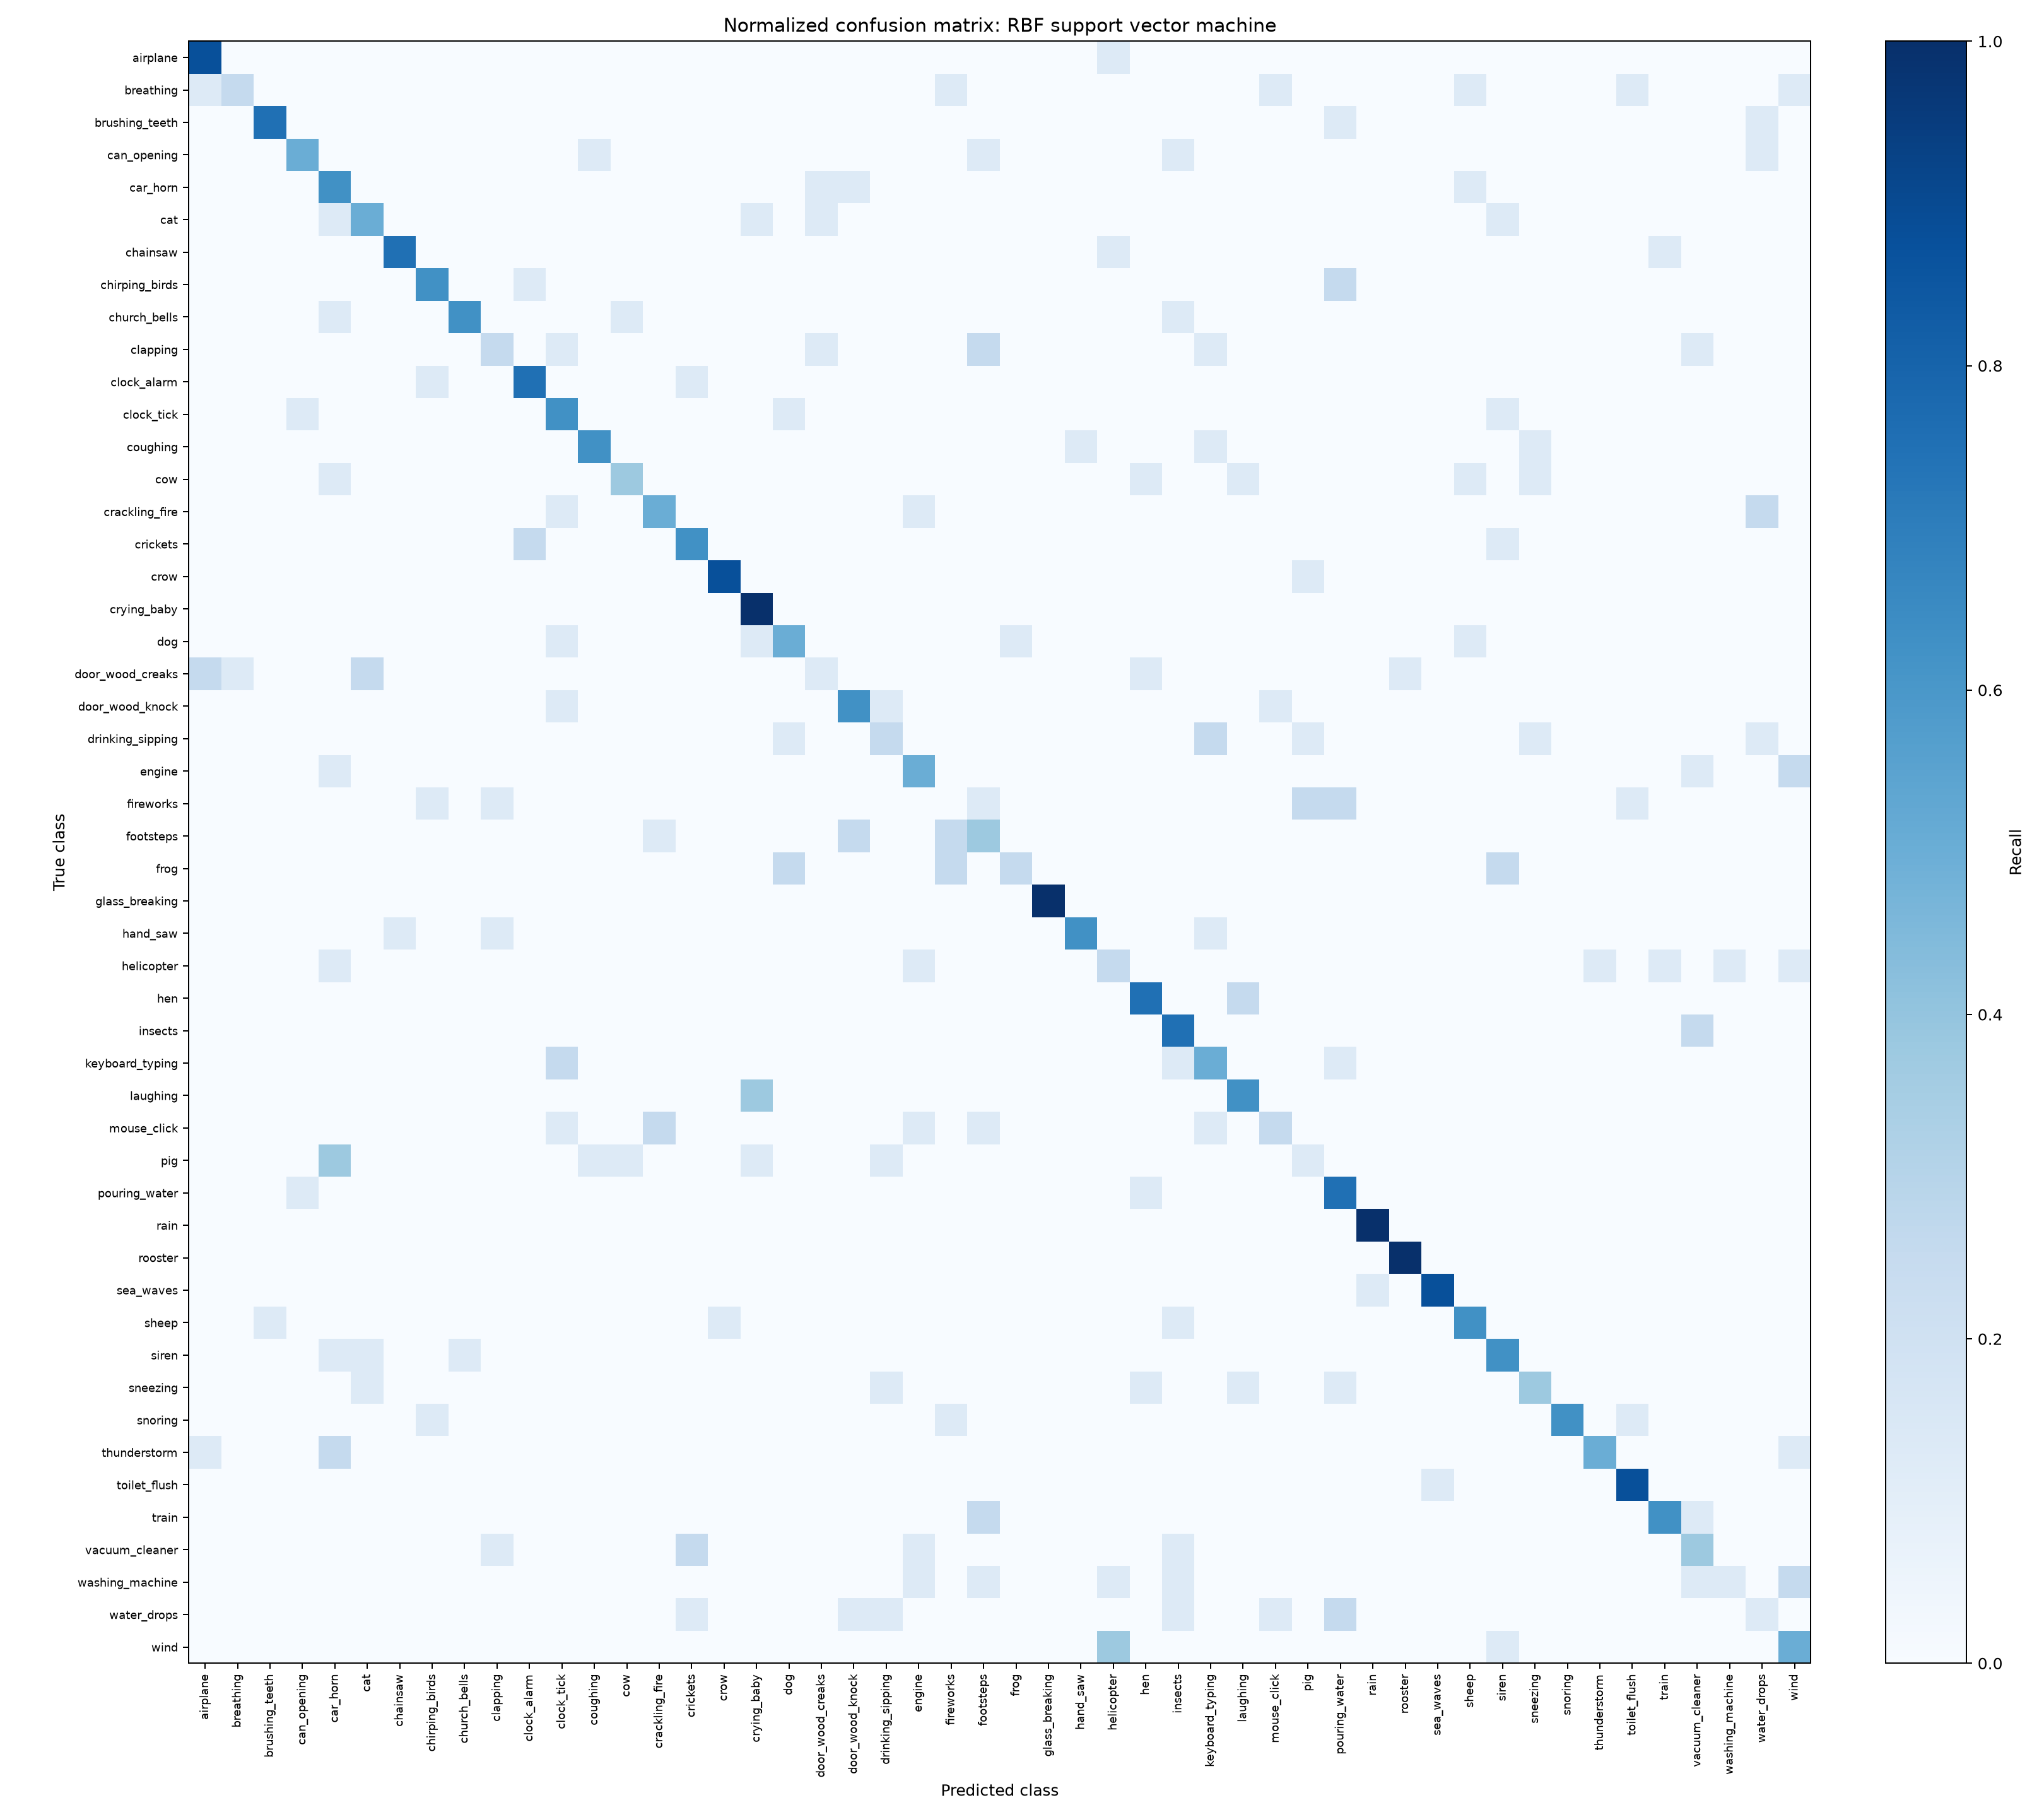

,true_class,predicted_class,count
0,laughing,crying_baby,3
1,pig,car_horn,3
2,wind,helicopter,3
3,chirping_birds,pouring_water,2
4,clapping,footsteps,2
5,crackling_fire,water_drops,2
6,crickets,clock_alarm,2
7,door_wood_creaks,airplane,2
8,door_wood_creaks,cat,2
9,drinking_sipping,keyboard_typing,2


In [5]:
display(Image(filename=RESULTS_DIRECTORY / "confusion_matrix.png", width=900))
display(pd.read_csv(RESULTS_DIRECTORY / "largest_confusions.csv").head(15))

## Conclusion

The most-frequent classifier provides a 2% accuracy lower bound for 50 balanced classes. The RBF support vector machine is the strongest of the first classical models and is the main candidate for the next round of feature and parameter improvements.